In [1]:
# In [1]:
import tensorflow as tf
import numpy as np
print(tf.__version__)
!python --version

2.19.1
Python 3.12.13


In [2]:
# In [3]:
train_path = './data/15.1 covid19/train'
test_path = './data/15.1 covid19/test'

In [3]:
# In [4]:
batch_size = 32
img_height = img_width = 100

In [4]:
# In [5]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(train_path, image_size=(img_width, img_height), label_mode='int', batch_size=batch_size)

Found 251 files belonging to 3 classes.


2026-09-03 01:02:05.533611: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-09-03 01:02:05.533638: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-09-03 01:02:05.533641: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
I0000 00:00:1788377525.533650 3720607 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1788377525.533674 3720607 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [5]:
# In [7]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(test_path, image_size=(img_width, img_height), label_mode='int', batch_size=batch_size)

Found 66 files belonging to 3 classes.


In [6]:
# In [ ]:
train_ds.prefetch(1)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [7]:
# In [9]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)

['Covid', 'Normal', 'Viral Pneumonia']


2026-09-03 01:02:05.830298: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


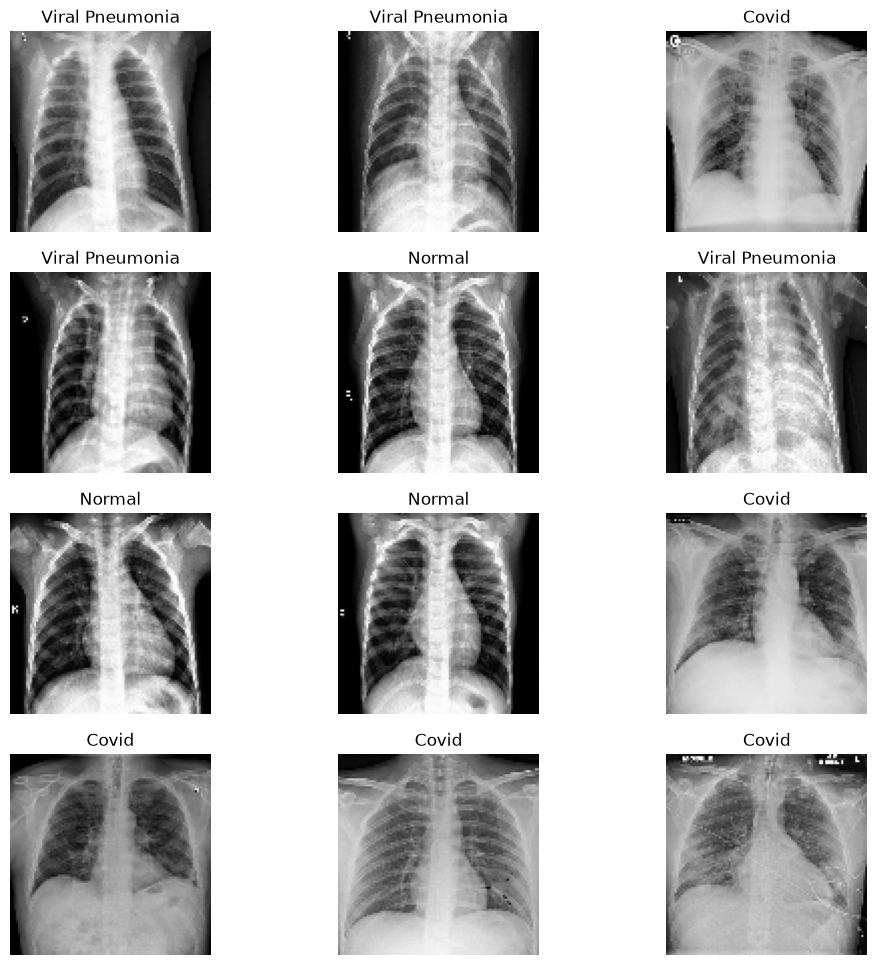

In [8]:
# In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
for img, label in val_ds.take(1):
    for i in range(12):
        ax = plt.subplot(4, 3, i + 1)
        plt.imshow(img[i].numpy().astype("uint8"))
        plt.title(class_names[label[i]])
        plt.axis("off")

In [9]:
norm_layer = tf.keras.layers.Rescaling(1./255)
zoom_layer = tf.keras.layers.RandomZoom(height_factor=(0.1,0.3), width_factor=(0.1,0.3))
rot_layer = tf.keras.layers.RandomRotation(factor=0.2)

In [10]:
# In [12]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential

In [11]:
# In [ ]:
def get_model(num_classes):

    model = Sequential([
                        norm_layer,
                        zoom_layer,
                        rot_layer,
                        Conv2D(16, (5, 5), padding='same', activation='relu'),
                        MaxPooling2D((2,2), strides=(1,1)),
                        BatchNormalization(),
                        Dropout(0.3),
                        Conv2D(16, (3, 3), padding='same', activation='relu'),
                        MaxPooling2D((2,2), strides=(2,2)),
                        Dropout(0.3),
                        Flatten(),
                        Dense(256, activation='relu'),
                        Dropout(0.5),
                        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  metrics = ['accuracy'])
    return model

In [12]:
model = get_model(num_classes=num_classes)

In [13]:
history = model.fit(train_ds,validation_data = val_ds, epochs=50)

Epoch 1/50


/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-09-03 01:02:06.494266: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - accuracy: 0.4622 - loss: 4.0433 - val_accuracy: 0.6212 - val_loss: 1.0681
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.5817 - loss: 4.2067 - val_accuracy: 0.5303 - val_loss: 1.2531
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.5857 - loss: 5.4415 - val_accuracy: 0.5909 - val_loss: 1.5067
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.5418 - loss: 5.5797 - val_accuracy: 0.5606 - val_loss: 0.9863
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.6215 - loss: 4.8045 - val_accuracy: 0.5909 - val_loss: 1.1734
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.6096 - loss: 4.1779 - val_accuracy: 0.7576 - val_loss: 0.6056
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.6614 - loss: 5.6306 - val_accuracy: 0.6212 - val_loss: 0.9102
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.6892 - loss: 4.7408 - val_accuracy: 0.7121 - val_loss: 0.7094
Epoch 9/5

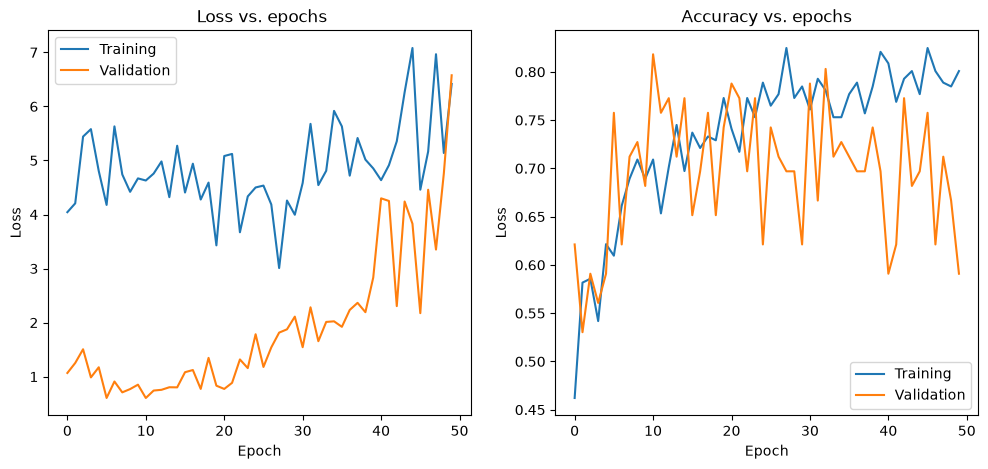

In [14]:
# In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))

fig.add_subplot(121)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title(' Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='best')

fig.add_subplot(122)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='best')

plt.show()

Predictions

In [15]:
# In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator()

test_ds = test_datagen.flow_from_directory(test_path,
    target_size=(img_height, img_width),
    batch_size = 1,
    class_mode = 'categorical',
    color_mode = "rgb",
    shuffle=False,
    seed = 2021)

Found 66 images belonging to 3 classes.


In [16]:
# In [ ]:
test_ds.reset()
predictions = model.predict(test_ds, steps=len(test_ds.filenames), verbose=1)

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [17]:
# In [ ]:
import pandas as pd

predicted_class_indices = np.argmax(predictions, axis=1)
labels = (test_ds.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred_labels = [labels[k] for k in predicted_class_indices]

filenames = test_ds.filenames
results = pd.DataFrame({"Filename": filenames, "Predictions": pred_labels})
results.tail(60)

,Filename,Predictions
6,Covid/0112.jpg,Covid
7,Covid/0113.jpg,Covid
8,Covid/0115.jpeg,Covid
9,Covid/0118.jpeg,Normal
10,Covid/0119.jpeg,Viral Pneumonia
11,Covid/0120.jpg,Covid
12,Covid/094.png,Covid
13,Covid/096.png,Normal
14,Covid/098.jpeg,Covid
15,Covid/COVID-00003b.jpg,Covid
